In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from anjana.anonymity import (
    k_anonymity_inner,
    k_anonymity,
    l_diversity,
    t_closeness,
    alpha_k_anonymity,
)
from masking_effects_on_xai_techniques import finding_k
from masking_effects_on_xai_techniques import anonymized_preprocessor as anon_prep
import masking_effects_on_xai_techniques.hierarchies as hi

from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler

# Preprocessing

In [2]:
path = "../data/usa_house/"

In [3]:
df = pd.read_csv(path + "data.csv")
len_data = len(df)

# Clean the data
df.dropna(inplace=True)
df = df.drop("Address", axis=1)

len_clean_data = len(df)
print(f"Dropped {len_data - len_clean_data} rows")

Dropped 0 rows


In [4]:
df["Price"]

0       1.059034e+06
1       1.505891e+06
2       1.058988e+06
3       1.260617e+06
4       6.309435e+05
            ...     
4995    1.060194e+06
4996    1.482618e+06
4997    1.030730e+06
4998    1.198657e+06
4999    1.298950e+06
Name: Price, Length: 5000, dtype: float64

We want to make it a classification problem. We bin the target feature into bins. But first we remove outliers

<Axes: >

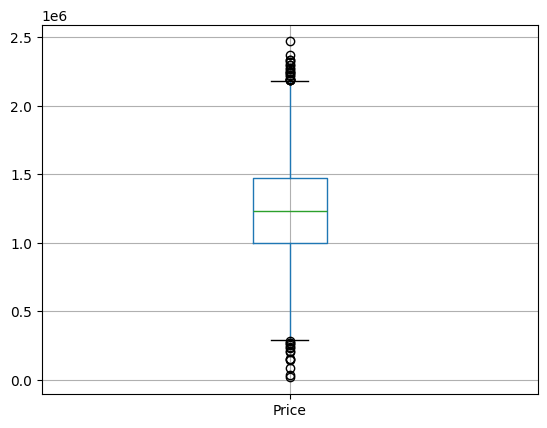

In [5]:
df.boxplot(column=["Price"])

In [6]:
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    return df[column].between(lower_bound, upper_bound)

In [7]:
df = df[remove_outliers_iqr(df, "Price")].reset_index(drop=True)

In [8]:
df.shape

(4965, 6)

In [9]:
df["Price"] = pd.cut(df["Price"], bins=6, include_lowest=True)

In [10]:
# df['Price'] = pd.qcut(df['Price'], 6)

In [11]:
df["Price"].value_counts()

Price
(918226.922, 1233686.591]     1573
(1233686.591, 1549146.26]     1567
(602767.253, 918226.922]       750
(1549146.26, 1864605.929]      742
(285414.825, 602767.253]       170
(1864605.929, 2180065.598]     163
Name: count, dtype: int64

In [12]:
le = LabelEncoder()

df["Price"] = le.fit_transform(df["Price"])

for i, class_label in enumerate(le.classes_):
    print(f"Original: {class_label} -> Encoded: {i}")

Original: (285414.825, 602767.253] -> Encoded: 0
Original: (602767.253, 918226.922] -> Encoded: 1
Original: (918226.922, 1233686.591] -> Encoded: 2
Original: (1233686.591, 1549146.26] -> Encoded: 3
Original: (1549146.26, 1864605.929] -> Encoded: 4
Original: (1864605.929, 2180065.598] -> Encoded: 5


# Hiearchies

In [13]:
df.nunique()

Avg. Area Income                4965
Avg. Area House Age             4965
Avg. Area Number of Rooms       4965
Avg. Area Number of Bedrooms     255
Area Population                 4965
Price                              6
dtype: int64

All features are continous numbers, except the Avg. Area Number of Bedrooms. Therefore we set level of bins at 50 for all features except that single one. We set that at 5. Then there are approxmiately 50 elements in the first level

In [14]:
df.columns

Index(['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
       'Avg. Area Number of Bedrooms', 'Area Population', 'Price'],
      dtype='object')

In [15]:
hierarchies_path = "../hierarchies/usa_house"


def create_and_save(feat, n):
    hierarchies[feat] = hi.generate_qcut_hierarchy(df[feat], n)
    hi.save_hierarchy(hierarchies[feat], f"{hierarchies_path}/{feat}.csv")


categories = df.columns.to_list()
bedroom = "Avg. Area Number of Bedrooms"
categories.remove(bedroom)

hierarchies = dict()
for cat in categories:
    create_and_save(cat, 3)
    hierarchies[cat] = dict(
        pd.read_csv(f"../hierarchies/usa_house/{cat}.csv", header=None)
    )

create_and_save(bedroom, 3)
hierarchies[bedroom] = dict(
    pd.read_csv(f"../hierarchies/usa_house/{bedroom}.csv", header=None)
)

/home/kochc/projects/bachelor/Masking-Effects-on-XAI-Techniques/.venv/lib/python3.12/site-packages/pandas/core/indexes/base.py:7819: RuntimeWarning: invalid value encountered in cast
  result = np.asarray(values).astype(str)
/home/kochc/projects/bachelor/Masking-Effects-on-XAI-Techniques/.venv/lib/python3.12/site-packages/pandas/core/indexes/base.py:7819: RuntimeWarning: invalid value encountered in cast
  result = np.asarray(values).astype(str)
/home/kochc/projects/bachelor/Masking-Effects-on-XAI-Techniques/.venv/lib/python3.12/site-packages/pandas/core/indexes/base.py:7819: RuntimeWarning: invalid value encountered in cast
  result = np.asarray(values).astype(str)
/home/kochc/projects/bachelor/Masking-Effects-on-XAI-Techniques/.venv/lib/python3.12/site-packages/pandas/core/indexes/base.py:7819: RuntimeWarning: invalid value encountered in cast
  result = np.asarray(values).astype(str)
/home/kochc/projects/bachelor/Masking-Effects-on-XAI-Techniques/.venv/lib/python3.12/site-packages/p

# Anonymization

In [16]:
ident = []
sens_att = "Price"
quasi_ident = list(df.columns)
quasi_ident.remove(sens_att)

In [17]:
all_counts_and_features = []
for feat, items in hierarchies.items():
    for item in items.values():
        length = len(item.unique())
        all_counts_and_features.append((length, feat))
sorted_data = sorted(all_counts_and_features, key=lambda x: x[0], reverse=True)
ordered_features = [feat for count, feat in sorted_data]

for feat, items in hierarchies.items():
    lengths = [f"{len(item.unique()):>4}" for item in items.values()]
    out = ", ".join(lengths)
    print(f"{feat:<15}: {out}")

print("Order in which features will be generalized:")
print(ordered_features)

Avg. Area Income: 4965,    3,    2,    1
Avg. Area House Age: 4965,    3,    2,    1
Avg. Area Number of Rooms: 4965,    3,    2,    1
Area Population: 4965,    3,    2,    1
Price          :    6,    3,    2,    1
Avg. Area Number of Bedrooms:  255,    3,    2,    1
Order in which features will be generalized:
['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms', 'Area Population', 'Avg. Area Number of Bedrooms', 'Price', 'Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms', 'Area Population', 'Price', 'Avg. Area Number of Bedrooms', 'Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms', 'Area Population', 'Price', 'Avg. Area Number of Bedrooms', 'Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms', 'Area Population', 'Price', 'Avg. Area Number of Bedrooms']


In [18]:
%%time
k = 10
supp_level = 20
anon_df, supp_n, hiear = k_anonymity_inner(
    df, ident, quasi_ident, k, supp_level, hierarchies
)
max_supp_n = int(round(len(df) * supp_level / 100, 0))
print(f"Max rows that can be suppressed: {max_supp_n}")
print(f"Rows suppressed                : {supp_n}")
print(f"% of allowed rows suppressed   : {round(supp_n / max_supp_n * 100, 1)}%")
print(f"Generalization level           : {sum(hiear.values())}")
hiear

Max rows that can be suppressed: 993
Rows suppressed                : 232
% of allowed rows suppressed   : 23.4%
Generalization level           : 5
CPU times: user 1.24 s, sys: 181 ms, total: 1.42 s
Wall time: 1.42 s


{'Avg. Area Income': 1,
 'Avg. Area House Age': 1,
 'Avg. Area Number of Rooms': 1,
 'Avg. Area Number of Bedrooms': 1,
 'Area Population': 1}

In [19]:
# Normalize df to train model on
tmp = {}
features = df.columns.tolist()
features.remove("Price")
scaler = StandardScaler()

X_scaled_array = scaler.fit_transform(df[features])
df_enc = pd.concat(
    [pd.DataFrame(X_scaled_array, columns=features), df["Price"]], axis=1
)

In [20]:
# k_list = [2, 4, 6, 8, 9, 10, 11, 12]
anon_data = finding_k.generate_k_anonymity_data(
    df,
    20,
    ident,
    quasi_ident,
    hierarchies,  # , k_list
)
anon_data.insert(0, df_enc)

Anonymizing for k=2
Anonymizing for k=4
Anonymizing for k=8
Anonymizing for k=16
Anonymizing for k=32
Anonymizing for k=64
Anonymizing for k=128
Anonymizing for k=256
Done anonymizing


In [21]:
clf = MLPClassifier(
    solver="sgd",
    alpha=1e-5,
    hidden_layer_sizes=(10),
    random_state=1,
    max_iter=1000,
)
models, scores = finding_k.train_models(anon_data, "Price", hierarchies_path, clf)

0.74269889224572
0.5503524672708963
0.5325264750378215
0.5473847747281202


/home/kochc/projects/bachelor/Masking-Effects-on-XAI-Techniques/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


0.5332936979785969
0.4994075829383886
0.4809206541490006
0.3898936170212766
0.3732208750658935


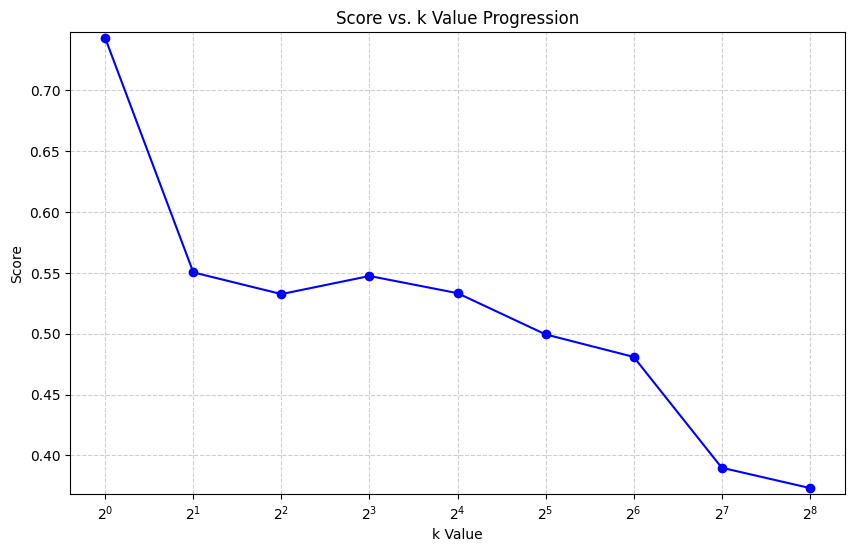

In [22]:
finding_k.plot_k_vs_score(scores, [1, 2, 4, 8, 16, 32, 64, 128, 256])

In [23]:
df.to_csv(path + "clean.csv", index=False)